# ESA Worldcover

**Nostradamus - Cube in a Box Demo Series**

---

*   **Objective:** Load and plot ESA Worldcover data.
*   **Products used:** [`esa_worldcover`](http://localhost/explorer/products/esa_worldcover)
*   **Source:** [Planetary Computer Catalog](https://planetarycomputer.microsoft.com/dataset/esa-worldcover)

---

## Background

This dataset, produced by The European Space Agency (ESA) WorldCover product provides global land cover maps for the years 2020 and 2021 at 10 meter resolution based on the combination of Sentinel-1 radar data and Sentinel-2 imagery. The discrete classification maps provide 11 classes defined using the Land Cover Classification System (LCCS) developed by the United Nations (UN) Food and Agriculture Organization (FAO). The map images are stored in cloud-optimized GeoTIFF format.

The WorldCover product is developed by a consortium of European service providers and research organizations. VITO (Belgium) is the prime contractor of the WorldCover consortium together with Brockmann Consult (Germany), CS SI (France), Gamma Remote Sensing AG (Switzerland), International Institute for Applied Systems Analysis (Austria), and Wageningen University (The Netherlands).

Two versions of the WorldCover product are available:
- WorldCover 2020 produced using v100 of the algorithm
- WorldCover 2021 produced using v200 of the algorithm

Since the WorldCover maps for 2020 and 2021 were generated with different algorithm versions (v100 and v200, respectively), changes between the maps include both changes in real land cover and changes due to the used algorithms.

## Description

This notebook demonstrates how to load and visualize the ESA Worldcover product, including inspecting measurements and using custom colormaps; and is similar to [ESRI_Land_Cover.ipynb](ESRI_Land_Cover.ipynb).

***

In [1]:
import sys
sys.path.insert(1, '../utils/')

In [2]:
# reload module before executing code
%load_ext autoreload
%autoreload 2

import datacube
import time
import numpy as np
from utils.nostra_dc import get_product_bbox
from utils.nostra_mapping import bbox_to_polygon, display_crosshair, MapHandler
from utils.nostra_plotting import plot_da_categories
from utils.nostra_tools import style_output_cells

from planetary_computer import sign_url  # needed to access planetary-computer collection

### Connect to the datacube

In [3]:
dc = datacube.Datacube(app='ESA_Worlcover')

## Describe product measurements

In [4]:
dc.list_measurements().loc['esa_worldcover']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
map,map,uint8,1,0.0,[classification],"{'data': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'v..."


## Load ESRI Land Cover data from the datacube

As this product contains only a single integer band for a limited number of times, and consequently is way lighter than other available products, we will process it the light way, meaning without Daskerization (as in other products notebooks).

In [5]:
# Check if default bbox is contained within the datacube
# and allow user to draw bbox if not.

product = 'esa_worldcover'

# configure a default bounding box and visualize it
lat, lon = 22.821, 28.518
buffer = 0.1
default_bbox = (lon - buffer, lat - buffer, lon + buffer, lat + buffer)

product_bbox = get_product_bbox(dc, product, split_size=10, stability_threshold=4)

is_contained =(default_bbox[0] >= product_bbox[0] and
               default_bbox[1] >= product_bbox[1] and
               default_bbox[2] <= product_bbox[2] and
               default_bbox[3] <= product_bbox[3]
              )

In [6]:
# Create an instance of MapHandler
map_handler = MapHandler()
m, drc = map_handler.create_map(vect=[bbox_to_polygon(default_bbox), bbox_to_polygon(product_bbox)],
                               draw_rect=True)
display(m)

# append crosshair
time.sleep(2)  # make sure m is fully displayed
display_crosshair()

Map(center=[25.5, 30.0], controls=(AttributionControl(options=['position', 'prefix'], position='bottomright'),…

<IPython.core.display.Javascript object>

In [7]:
# Warn in case of full AoI
aoi_poly = map_handler.aoi_tupple

if aoi_poly is None:
    aoi_poly = tuple(default_bbox)
    if not is_contained:
        style_output_cells('salmon', border_color='red', border_width='2px')
        print('The area of interest polygon is located outside of the product extent.' + \
              '\nPlease draw a new area of interest in the previous cell.')
    else:
        # When is_contained is True and no polygon drawn - this is actually OK!
        style_output_cells()
        print('Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.')
else:
    # A polygon was drawn
    style_output_cells()
    print('Custom area of interest polygon has been created.')

Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.


In [8]:
# Create a query object (we don't need to define time range and measurements as it is a
# single time and single band product) and use it to load the data

query = {
    'product': product,
    'x': (aoi_poly[0], aoi_poly[2]),
    'y': (aoi_poly[1], aoi_poly[3]),
    'output_crs': 'epsg:6933',
    'resolution':30,
    'patch_url': sign_url,
}

ds = dc.load(**query)
print(ds)

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 2, y: 787, x: 644)
Coordinates:
  * time         (time) datetime64[ns] 16B 2020-07-01T23:59:59.500000 2021-07...
  * y            (y) float64 6kB 2.849e+06 2.849e+06 ... 2.825e+06 2.825e+06
  * x            (x) float64 5kB 2.742e+06 2.742e+06 ... 2.761e+06 2.761e+06
    spatial_ref  int32 4B 6933
Data variables:
    map          (time, y, x) uint8 1MB 60 60 60 60 60 60 ... 40 40 40 60 60 60
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


## Plot ESA Worldcover

To do so you need to first define the style of each Land Cover category

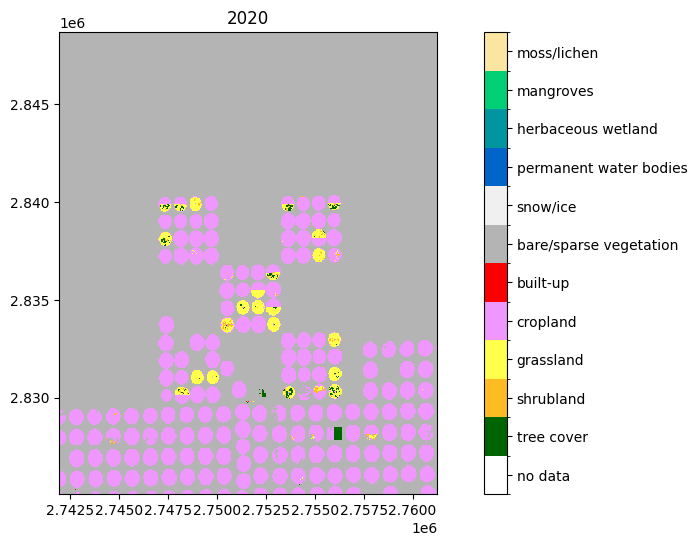

In [9]:
# Plot the first time

# define Value, Color and Label triplets
vcls = [
    (0, (255,255,255), 'no data'),
    (10, (0,100,0), 'tree cover'),
    (20, (255,187,34), 'shrubland'),
    (30, (255,255,76), 'grassland'),
    (40, (240,150,255), 'cropland'),
    (50, (250,0,0), 'built-up'),
    (60, (180,180,180), 'bare/sparse vegetation'),
    (70, (240,240,240), 'snow/ice'),
    (80, (0,100,200), 'permanent water bodies'),
    (90, (0,150,160), 'herbaceous wetland'),
    (95, (0,207,117), 'mangroves'),
    (100, (250,230,160), 'moss/lichen')
]

da = ds["map"].isel(time=0)
plot_da_categories(da, vcls, title= da.time.values.astype('datetime64[Y]').astype(int) + 1970,
                   cb=True, figsize=(12, 6))

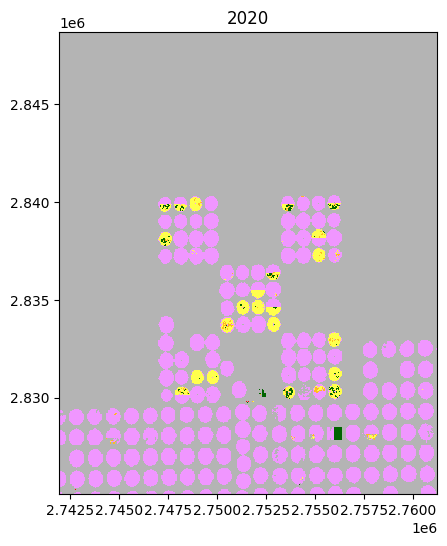

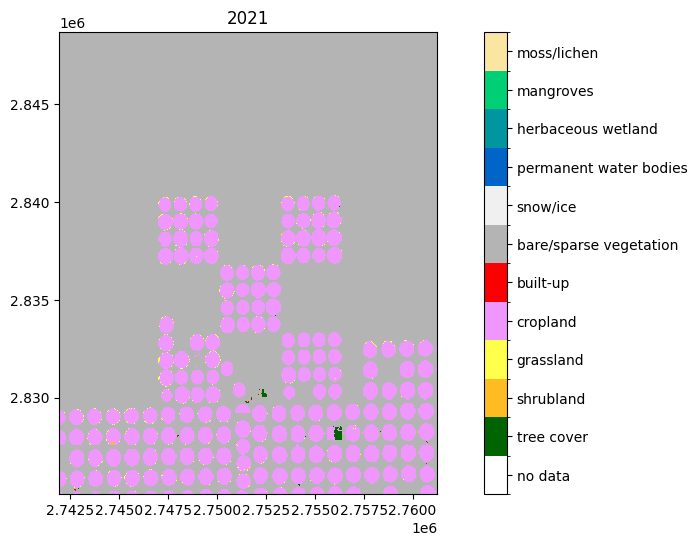

In [10]:
# Plot all time, displaying a colorbar only midway

for idx in range(len(ds.time)):
    da = ds["map"].isel(time=idx)
    cb = idx == np.floor(len(ds.time) / 2)  # display colorbar midway
    plot_da_categories(da, vcls, title= da.time.values.astype('datetime64[Y]').astype(int) + 1970,
                       cb=cb, figsize=(12, 6))

***

## Additional information

**License:** The code in this notebook is slighly modified from https://github.com/digitalearthafrica/deafrica-sandbox-notebooks and licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [11]:
print(datacube.__version__)

1.9.14


**Last tested:**

In [12]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-03-04'

In [13]:
!pip freeze

affine==2.4.0
ai-edge-litert==2.1.2
aiobotocore==3.2.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aioitertools==0.13.0
aiosignal==1.4.0
alembic==1.18.4
annotated-types==0.7.0
antimeridian==0.4.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.2.0
attrs==25.4.0
babel==2.18.0
backports.strenum==1.2.8
beautifulsoup4==4.14.3
black==26.1.0
bleach==6.3.0
bokeh==3.8.2
boltons==25.0.0
boto3==1.42.55
botocore==1.42.55
branca==0.8.2
cachetools==7.0.1
cattrs==26.1.0
certifi==2026.2.25
certipy==0.2.2
cffi==2.0.0
cftime==1.6.5
charset-normalizer==3.4.4
ciso8601==2.3.3
click==8.3.1
click-plugins==1.1.1.2
cligj==0.7.2
cloudpickle==3.1.2
comm==0.2.3
contourpy==1.3.3
cryptography==46.0.5
cycler==0.12.1
dask==2025.7.0
dask-image==2025.11.0
dask_labextension==7.0.0
datacube==1.9.14
datadog==0.52.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
deprecat==2.1.3
distributed==2025.7.0
eodatasets3==1.9.3
executing==2.2.1
fastjsonschema==2.21.2
fiona==